In [1]:
CUDA_VISIBLE_DEVICES=1
import os
import wandb
import argparse
from blackbox_api import BlackBoxAPI
from config import AuditConfig
from data_loader import load_jigsaw, load_sbic_and_train_api
from surrogate_model import (compute_group_auc_difference,
                             load_lora_bert_surrogate, predict_with_model,
                             train_surrogate)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

/home/copresence/miniconda3/envs/NLP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-12-16 18:53:30.976905: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765907610.993186   64858 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765907610.998157   64858 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1765907611.011062   64858 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more th

In [2]:
from sklearn.metrics import roc_auc_score; from scipy.stats import spearmanr
from tqdm import tqdm

In [3]:
import time
from typing import Dict, List, Tuple#
import surrogate_model
import numpy as np
import pandas as pd
import torch
import wandb
import evaluation
from evaluation import (
    compute_blackbox_auc_difference,
    evaluate_inner_loop,
    evaluate_outer_loop,
)
from torch.nn.functional import sigmoid, softmax

In [4]:
import optimization
from optimization import eval_h, compute_lora_gradient

import utils                      # import the module object
                     # reloads utils.py

# IMPORTANT: rebind the names you use, because `from utils import X`
# copies references that won't update automatically on reload.
from utils import (
    delta_progress,
    df_map,
    stratified_sampling,
    plot_weight_evolution,
    random_ordered_sampling,
    stratified_ordered_sampling,
)
import time
import numpy as np
import pandas as pd
import torch

from dataclasses import dataclass
from typing import Callable, Dict, Any, Tuple, List

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import StandardScaler
from scipy.stats import norm

In [ ]:
 # === Load audit dataset D ===
dataset_D = load_jigsaw()
dataset_D = dataset_D.sample(n=10000, random_state=41).reset_index(drop=True)
api = BlackBoxAPI()
# === Train black-box ===
_ = load_sbic_and_train_api(api, path="../../SBIC_group.csv")

In [9]:
import importlib, utils
importlib.reload(utils)

<module 'utils' from '/mnt/sda/david/activeAuditing/activeAuditing231025/utils.py'>

In [10]:
def initialize_dataset_S(size: int, D, api) -> pd.DataFrame:
        S = utils.stratified_sampling(size, D)
        
        S = S.copy()
        
        S["bb_score"] = query_points(S["text"].tolist(), api)
        return S

In [11]:
size_T_seed = 500
epochs_sur = 20
batch_size = 64

In [12]:
tokenizer, base_model = surrogate_model.load_lora_bert_surrogate()

# Map the full D once
D, df_D_mapped = df_map(dataset_D, tokenizer, False)
df_D_mapped = df_D_mapped  # promote to member
inputs_D = {
    "input_ids": torch.tensor(df_D_mapped["input_ids"]).long(),
    "attention_mask": torch.tensor(df_D_mapped["attention_mask"]).long(),
    "labels": torch.tensor(df_D_mapped["labels"]).long(),
    "id": df_D_mapped["id"],
}

# Seed S
S = initialize_dataset_S(size_T_seed, D, api)

df_S, df_S_mapped = df_map(S, tokenizer, True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/hateBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Parameter 'function'=<function df_map.<locals>.<lambda> at 0x7f056d6a2840> of the transform datasets.arrow_dataset.Dataset._map_single couldn't be hashed properly, a random hash was used instead. Make sure your transforms and parameters are serializable with pickle or dill for the dataset fingerprinting and caching to work. If you reuse this transform, the caching mechanism will consider it to be different from the previous calls and recompute everything. This warning is only showed once. Subsequent hashing failures won't be showed.


[INFO] Group mapping used: {'black': 0, 'white': 1}


Map: 100%|██████████| 10000/10000 [00:00<00:00, 12207.52 examples/s]


[Init S] contingency
 true_label    0    1
group               
0           125  125
1           125  125
[INFO] Group mapping used: {0: 0, 1: 1}


Map: 100%|██████████| 500/500 [00:00<00:00, 11930.14 examples/s]


## Train surrogate on some initial data $(n=100)$

In [13]:
needed = ["input_ids", "attention_mask", "labels", "bb_score"]
if "token_type_ids" in df_S_mapped.column_names:
    needed.append("token_type_ids")

df_S_train = df_S_mapped.remove_columns(
    [c for c in df_S_mapped.column_names if c not in needed]
).with_format("torch", columns=needed)

In [14]:
import importlib, surrogate_model
importlib.reload(surrogate_model)
# Train surrogate on S
surrogate = surrogate_model.train_surrogate(
    base_model, tokenizer, df_S_train, epochs_sur, batch_size
)

/home/copresence/miniconda3/envs/NLP/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(


Step   0 | MSE=0.1010 | Rank=0.1034 | Loss=0.1029 | Logits:[0.07,0.63] | Probs:[0.517,0.653]
Step   0 | MSE=0.0816 | Rank=0.1024 | Loss=0.0982 | Logits:[0.11,0.71] | Probs:[0.529,0.671]


KeyboardInterrupt: 

In [ ]:
def get_probs_batch(model, tokenizer, texts, bs=64):
    device = next(model.parameters()).device; model.eval(); outs=[]
    with torch.inference_mode():
        for i in tqdm(range(0, len(texts), bs)):
            enc = tokenizer(texts[i:i+bs], return_tensors="pt", padding=True, truncation=True).to(device)
            logits = model(**enc).logits
            probs = (torch.sigmoid(logits).squeeze(-1) if logits.shape[-1]==1
                     else torch.softmax(logits, dim=-1)[:,1])
            outs.append(probs.detach().cpu())
    return torch.cat(outs).numpy()

In [ ]:
def calibrated_predict_batched(surrogate, texts, tokenizer, batch_size=32, groups=None):
    """Batched inference with pre-fitted calibrator"""
    device = getattr(surrogate, "device", "cuda" if torch.cuda.is_available() else "cpu")
    surrogate.eval()
    groupwise = hasattr(surrogate, "calibrators") and len(surrogate.calibrators) > 1
    calibrated_probs = []
    
    with torch.no_grad():
        for start in tqdm(range(0, len(texts), batch_size)):
            batch_texts = texts[start:start + batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt").to(device)
            probs = sigmoid(surrogate(**inputs).logits).cpu().numpy().flatten()
            
            if groupwise and groups is not None:
                batch_groups = np.array(groups[start:start + batch_size])
                calibrated = np.array([surrogate.calibrators.get(g, lambda x: x).predict([p])[0] for p, g in zip(probs, batch_groups)])
            else:
                calibrator = surrogate.calibrators.get("_global") if hasattr(surrogate, "calibrators") else getattr(surrogate, "calibrator", None)
                calibrated = calibrator.predict(probs) if calibrator is not None else probs
            
            calibrated_probs.append(calibrated)
    
    return np.concatenate(calibrated_probs)

In [ ]:
X = df_D_mapped["text"]
y = np.array(df_D_mapped["labels"])
a = np.array(df_D_mapped["group"])
bb = api.predict_scores(X)            # shape (n,) in [0,1]

su = get_probs_batch(surrogate, tokenizer, X, bs=128)       # shape (n,) in [0,1]


100%|██████████| 79/79 [00:31<00:00,  2.49it/s]


In [ ]:
base = get_probs_batch(base_model, tokenizer, X, bs=128)

100%|██████████| 79/79 [00:32<00:00,  2.44it/s]


In [ ]:
# After training, check if surrogate learned anything
surrogate.eval()
test_texts = S["text"].head(20).tolist()
test_bb_scores = S["bb_score"].head(20).values

surrogate_preds = surrogate_model.predict_with_model(
    test_texts, tokenizer, surrogate, batch_size=16
)

print("\nSample predictions after training:")
for i in range(min(10, len(test_texts))):
    print(f"Text: {test_texts[i][:80]}...")
    print(f"BB score: {test_bb_scores[i][0]:.3f}, Surrogate: {surrogate_preds[i]:.3f}")
    print()

# Check correlation
from scipy.stats import spearmanr
corr, _ = spearmanr(test_bb_scores, surrogate_preds)
print(f"Surrogate-BB Spearman on training sample: {corr:.3f}")


Sample predictions after training:
Text: "The Klan began in Tennessee, in the small town of Pulaski, near Memphis. It was...
BB score: 0.300, Surrogate: 0.361

Text: Indeed, 73 years ago civil rights for Blacks were almost nonexistent.  Some came...
BB score: 0.159, Surrogate: 0.311

Text: Yes she should be fired.  Outspoken conservative former MLB star Curt Schilling ...
BB score: 0.370, Surrogate: 0.291

Text: "The bigger picture here is about unarmed people being killed by the police."  I...
BB score: 0.134, Surrogate: 0.200

Text: The Rockies have officially given up. Down 3 -0 in the 4th inning, they pull a g...
BB score: 0.170, Surrogate: 0.162

Text: Being an old black man, my first thought as I read the article was this guy must...
BB score: 0.543, Surrogate: 0.301

Text: Wayne was an honor student. He credits a strong academic work ethic for his succ...
BB score: 0.101, Surrogate: 0.216

Text: The problem with these modern revisionist social justice statements is that most...

In [ ]:
agree_acc = ((bb > 0.5) == (su > 0.5)).mean()
rank_rho = spearmanr(bb, su).correlation
auc_bb_0, auc_bb_1 = roc_auc_score(y[a==0], bb[a==0]), roc_auc_score(y[a==1], bb[a==1])
auc_su_0, auc_su_1 = roc_auc_score(y[a==0], su[a==0]), roc_auc_score(y[a==1], su[a==1])
dAUC_bb, dAUC_su = auc_bb_0 - auc_bb_1, auc_su_0 - auc_su_1
print(f"AgreeAcc={agree_acc:.3f} | Spearman={rank_rho:.3f} | ΔAUC_bb={dAUC_bb:.3f} | ΔAUC_su={dAUC_su:.3f} | |Δ| gap={abs(dAUC_bb-dAUC_su):.3f}")

AgreeAcc=0.758 | Spearman=0.676 | ΔAUC_bb=-0.181 | ΔAUC_su=-0.176 | |Δ| gap=0.005


In [ ]:
from sklearn.isotonic import IsotonicRegression

def calibrate_surrogate(surrogate, calibration_data, tokenizer, batch_size=16):
    """
    Calibrate surrogate to match blackbox scores
    calibration_data: list of (text, blackbox_score) tuples
    """
    # Extract texts and scores
    texts = [x for x, _ in calibration_data]
    blackbox_scores = np.array([score for _, score in calibration_data])
    
    # Get surrogate predictions using proper inference
    surrogate_scores = predict_with_model(texts, tokenizer, surrogate, batch_size)
    
    # Fit isotonic regression: f(surrogate_score) → blackbox_score
    calibrator = IsotonicRegression(out_of_bounds='clip', increasing=True)
    calibrator.fit(surrogate_scores, blackbox_scores)
    
    # Create a calibrated predict function
    def calibrated_predict(texts, batch_size=16):
        uncalibrated_scores = predict_with_model(texts, tokenizer, surrogate, batch_size)
        return calibrator.predict(uncalibrated_scores)
    
    # Store calibration components
    surrogate.calibrator = calibrator
    surrogate.calibrated_predict = calibrated_predict
    
    return surrogate



In [ ]:

series_float = S["bb_score"].apply(lambda x: x[0])
calibration_data = list(zip(S["text"], series_float))

surrogate = calibrate_surrogate(surrogate, calibration_data,tokenizer)

In [ ]:
X = df_D_mapped["text"]
y = np.array(df_D_mapped["labels"])
a = np.array(df_D_mapped["group"])
bb = api.predict_scores(X)            # shape (n,) in [0,1]
su = calibrated_predict_batched(surrogate, X, tokenizer, batch_size=128)       # shape (n,) in [0,1]


100%|██████████| 79/79 [00:32<00:00,  2.42it/s]


In [ ]:
agree_acc = ((bb > 0.5) == (su > 0.5)).mean()
rank_rho = spearmanr(bb, su).correlation
auc_bb_0, auc_bb_1 = roc_auc_score(y[a==0], bb[a==0]), roc_auc_score(y[a==1], bb[a==1])
auc_su_0, auc_su_1 = roc_auc_score(y[a==0], su[a==0]), roc_auc_score(y[a==1], su[a==1])
dAUC_bb, dAUC_su = auc_bb_0 - auc_bb_1, auc_su_0 - auc_su_1
print(f"AgreeAcc={agree_acc:.3f} | Spearman={rank_rho:.3f} | ΔAUC_bb={dAUC_bb:.3f} | ΔAUC_su={dAUC_su:.3f} | |Δ| gap={abs(dAUC_bb-dAUC_su):.3f}")

AgreeAcc=0.754 | Spearman=0.674 | ΔAUC_bb=-0.181 | ΔAUC_su=-0.174 | |Δ| gap=0.007


## How many queries do I need for a good surrogate?

In [ ]:
import importlib
importlib.reload(surrogate_model)

<module 'surrogate_model' from '/mnt/sda/david/activeAuditing/activeAuditing231025/surrogate_model.py'>

In [ ]:
p_query = np.arange(100,2000,200)
data=[]



for p in tqdm(p_query):
    tokenizer, base_model = surrogate_model.load_lora_bert_surrogate()
    
    # Map the full D once
    D, df_D_mapped = df_map(dataset_D, tokenizer, False)
    df_D_mapped = df_D_mapped  # promote to member
    inputs_D = {
        "input_ids": torch.tensor(df_D_mapped["input_ids"]).long(),
        "attention_mask": torch.tensor(df_D_mapped["attention_mask"]).long(),
        "labels": torch.tensor(df_D_mapped["labels"]).long(),
        "id": df_D_mapped["id"],
    }

   
    # Seed S
    S = initialize_dataset_S(p, D, api)

    df_S, df_S_mapped = df_map(S, tokenizer, True)
    needed = ["input_ids", "attention_mask", "labels", "bb_score"]
    if "token_type_ids" in df_S_mapped.column_names:
        needed.append("token_type_ids")

    df_S_train = df_S_mapped.remove_columns(
        [c for c in df_S_mapped.column_names if c not in needed]
    ).with_format("torch", columns=needed)

    
    # Train surrogate on S
    surrogate = surrogate_model.train_surrogate(
        base_model, tokenizer, df_S_train, epochs_sur, batch_size
    )

    
    # Usage
    series_float = S["bb_score"].apply(lambda x: x[0])
    calibration_data = list(zip(S["text"], series_float))

    surrogate = calibrate_surrogate(surrogate, calibration_data, tokenizer)
    X = df_D_mapped["text"]
    y = np.array(df_D_mapped["labels"])
    a = np.array(df_D_mapped["group"])
    bb = api.predict_scores(X)            # shape (n,) in [0,1]
    su = calibrated_predict_batched(surrogate, X, tokenizer, batch_size=128)    

    agree_acc = ((bb > 0.5) == (su > 0.5)).mean()
    rank_rho = spearmanr(bb, su).correlation
    auc_bb_0, auc_bb_1 = roc_auc_score(y[a==0], bb[a==0]), roc_auc_score(y[a==1], bb[a==1])
    auc_su_0, auc_su_1 = roc_auc_score(y[a==0], su[a==0]), roc_auc_score(y[a==1], su[a==1])
    dAUC_bb, dAUC_su = auc_bb_1 - auc_bb_0, auc_su_1 - auc_su_0
    print(f"AgreeAcc={agree_acc:.3f} | Spearman={rank_rho:.3f} | ΔAUC_bb={dAUC_bb:.3f} | ΔAUC_su={dAUC_su:.3f} | |Δ| gap={abs(dAUC_bb-dAUC_su):.3f}")

    data.append([p,agree_acc,rank_rho,dAUC_bb,dAUC_su,abs(dAUC_bb-dAUC_su)])

df_results = pd.DataFrame(data, columns=['p', 'agree_acc', 'rank_rho', 'dAUC_bb', 'dAUC_su', 'delta_gap'])
df_results.to_csv('results.csv', index=False)
print(f"Results saved to results.csv")


  0%|          | 0/10 [00:00<?, ?it/s]Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/hateBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[INFO] Group mapping used: {'black': 0, 'white': 1}


Map: 100%|██████████| 10000/10000 [00:01<00:00, 8793.70 examples/s]


[Init S] contingency
 true_label   0   1
group             
0           25  25
1           25  25
[INFO] Group mapping used: {0: 0, 1: 1}


Map: 100%|██████████| 100/100 [00:00<00:00, 7451.37 examples/s]
/home/copresence/miniconda3/envs/NLP/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(


...

[Init S] contingency
 true_label    0    1
group               
0           475  475
1           475  475
[INFO] Group mapping used: {0: 0, 1: 1}


Map: 100%|██████████| 1900/1900 [00:00<00:00, 12906.05 examples/s]
/home/copresence/miniconda3/envs/NLP/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(


Step   0 | MSE=0.0546 | Rank=0.0980 | Loss=0.0893 | Logits:[-0.25,0.35] | Probs:[0.438,0.587]
Step   0 | MSE=0.0768 | Rank=0.1023 | Loss=0.0972 | Logits:[-0.47,0.38] | Probs:[0.384,0.593]
{'loss': 0.0896, 'grad_norm': 0.3589518368244171, 'learning_rate': 0.00017857142857142857, 'epoch': 1.3333333333333333}
Step  10 | MSE=0.0391 | Rank=0.0955 | Loss=0.0843 | Logits:[-0.61,0.09] | Probs:[0.351,0.522]
Step  10 | MSE=0.0534 | Rank=0.0969 | Loss=0.0882 | Logits:[-0.54,0.21] | Probs:[0.368,0.552]
{'loss': 0.0817, 'grad_norm': 0.23680995404720306, 'learning_rate': 0.00035714285714285714, 'epoch': 2.6666666666666665}
Step  20 | MSE=0.0330 | Rank=0.0790 | Loss=0.0698 | Logits:[-1.36,-0.11] | Probs:[0.204,0.473]
Step  20 | MSE=0.0346 | Rank=0.0805 | Loss=0.0713 | Logits:[-1.19,0.10] | Probs:[0.234,0.526]
{'loss': 0.0646, 'grad_norm': 0.24843397736549377, 'learning_rate': 0.0004910714285714286, 'epoch': 4.0}
Step  30 | MSE=0.0301 | Rank=0.0644 | Loss=0.0575 | Logits:[-1.38,0.38] | Probs:[0.201,0.

100%|██████████| 10/10 [17:36<00:00, 105.61s/it]

AgreeAcc=0.832 | Spearman=0.837 | ΔAUC_bb=0.181 | ΔAUC_su=0.209 | |Δ| gap=0.028
Results saved to results.csv


In [ ]:

# -------------------------------------------------
# Config
# -------------------------------------------------
p_query = np.arange(100, 4000, 100)
data = []

rng = np.random.default_rng(41)   # reproducible but different S for each p

# -------------------------------------------------
# 0) bb_score EINMAL auf dem ganzen D berechnen
# -------------------------------------------------
# dataset_D: DataFrame mit Spalten: 'text', 'true_label', 'group', (ggf. ohne 'bb_score')
if "bb_score" not in dataset_D.columns:
    print("[INFO] Computing bb_score once for full D...")
    scores_full = api.predict_scores(dataset_D["text"].tolist())
    # scores_full kann Liste oder np.array sein
    dataset_D = dataset_D.copy()
    dataset_D["bb_score"] = scores_full

# -------------------------------------------------
# 1) Budget-Schleife
# -------------------------------------------------
for p in tqdm(p_query):

    # frischer Surrogat-BERT
    tokenizer, base_model = surrogate_model.load_lora_bert_surrogate()

    # --- Map volles D einmal (für Evaluation) ---
    D = dataset_D  # Alias, unverändert
    D_mapped_df, df_D_mapped = df_map(D, tokenizer, surrogate=False)

    inputs_D = {
        "input_ids": torch.tensor(df_D_mapped["input_ids"]).long(),
        "attention_mask": torch.tensor(df_D_mapped["attention_mask"]).long(),
        "labels": torch.tensor(df_D_mapped["labels"]).long(),
        "id": df_D_mapped["id"],
    }

    # -------------------------------------------------
    # 2) Repräsentative Stichprobe S aus D (OHNE Stratification)
    # -------------------------------------------------
    p_eff = min(p, len(D))
    S = D.sample(n=p_eff, replace=False,
                 random_state=int(rng.integers(1_000_000))).reset_index(drop=True)

    # --- Map S für Surrogat-Training (labels = bb_score) ---
    df_S, df_S_mapped = df_map(S, tokenizer, surrogate=True)
    needed = ["input_ids", "attention_mask", "labels", "bb_score"]
    if "token_type_ids" in df_S_mapped.column_names:
        needed.append("token_type_ids")

    df_S_train = (
        df_S_mapped
        .remove_columns([c for c in df_S_mapped.column_names if c not in needed])
        .with_format("torch", columns=needed)
    )

    # -------------------------------------------------
    # 3) Surrogat auf S trainieren
    # -------------------------------------------------
    surrogate = surrogate_model.train_surrogate(
        base_model, tokenizer, df_S_train, epochs_sur, batch_size
    )

    # -------------------------------------------------
    # 4) Surrogat auf S kalibrieren (gegen bb_score)
    # -------------------------------------------------
    # bb_score kann Liste von 1-Element-Listen oder Floats sein → robustes Handling:
    series_float = S["bb_score"].apply(
        lambda x: x[0] if isinstance(x, (list, tuple, np.ndarray)) else x
    )
    calibration_data = list(zip(S["text"], series_float))
    surrogate = calibrate_surrogate(surrogate, calibration_data, tokenizer)

    # -------------------------------------------------
    # 5) Evaluation auf VOLLEM D (unverzerrte ΔAUC)
    # -------------------------------------------------
    X = df_D_mapped["text"]
    y = np.array(df_D_mapped["labels"])
    a = np.array(df_D_mapped["group"])

    bb = api.predict_scores(X)               # shape (n,) in [0,1]
    bb = np.asarray(bb).reshape(-1)

    su = calibrated_predict_batched(
        surrogate, X, tokenizer, batch_size=128
    ).reshape(-1)

    # Agreement + Rank
    agree_acc = ((bb > 0.5) == (su > 0.5)).mean()
    rank_rho = spearmanr(bb, su).correlation

    # Gruppen-AUCs
    auc_bb_0 = roc_auc_score(y[a == 0], bb[a == 0])
    auc_bb_1 = roc_auc_score(y[a == 1], bb[a == 1])
    auc_su_0 = roc_auc_score(y[a == 0], su[a == 0])
    auc_su_1 = roc_auc_score(y[a == 1], su[a == 1])

    dAUC_bb = auc_bb_1 - auc_bb_0
    dAUC_su = auc_su_1 - auc_su_0
    gap = abs(dAUC_bb - dAUC_su)

    print(
        f"p={p:4d} | AgreeAcc={agree_acc:.3f} | Spearman={rank_rho:.3f} | "
        f"ΔAUC_bb={dAUC_bb:.3f} | ΔAUC_su={dAUC_su:.3f} | |Δ| gap={gap:.3f}"
    )

    data.append([p, agree_acc, rank_rho, dAUC_bb, dAUC_su, gap])

# -------------------------------------------------
# 6) Ergebnisse speichern
# -------------------------------------------------
df_results = pd.DataFrame(
    data,
    columns=["p", "agree_acc", "rank_rho", "dAUC_bb", "dAUC_su", "delta_gap"],
)
df_results.to_csv("results.csv", index=False)
print("Results saved to results.csv")


  0%|          | 0/39 [00:00<?, ?it/s]Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/hateBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[INFO] Group mapping used: {'black': 0, 'white': 1}


Map: 100%|██████████| 10000/10000 [00:00<00:00, 13403.35 examples/s]


[INFO] Group mapping used: {'black': 0, 'white': 1}


Map: 100%|██████████| 100/100 [00:00<00:00, 6791.52 examples/s]
/home/copresence/miniconda3/envs/NLP/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(


...

[INFO] Group mapping used: {'black': 0, 'white': 1}


Map: 100%|██████████| 3900/3900 [00:00<00:00, 12296.37 examples/s]
/home/copresence/miniconda3/envs/NLP/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(


Step   0 | MSE=0.0503 | Rank=0.1039 | Loss=0.0932 | Logits:[-0.35,0.46] | Probs:[0.413,0.613]
Step   0 | MSE=0.0410 | Rank=0.0999 | Loss=0.0881 | Logits:[-0.33,0.40] | Probs:[0.419,0.598]
{'loss': 0.088, 'grad_norm': 0.3896133601665497, 'learning_rate': 8.333333333333333e-05, 'epoch': 0.6451612903225806}
Step  10 | MSE=0.0419 | Rank=0.0970 | Loss=0.0859 | Logits:[-0.62,0.29] | Probs:[0.351,0.571]
Step  10 | MSE=0.0451 | Rank=0.1009 | Loss=0.0897 | Logits:[-0.48,0.25] | Probs:[0.383,0.562]
{'loss': 0.0863, 'grad_norm': 0.23506836593151093, 'learning_rate': 0.00016666666666666666, 'epoch': 1.2903225806451613}
Step  20 | MSE=0.0388 | Rank=0.0957 | Loss=0.0843 | Logits:[-0.87,-0.01] | Probs:[0.294,0.498]
Step  20 | MSE=0.0392 | Rank=0.0971 | Loss=0.0855 | Logits:[-1.02,0.03] | Probs:[0.264,0.508]
{'loss': 0.0789, 'grad_norm': 0.21979336440563202, 'learning_rate': 0.00025, 'epoch': 1.935483870967742}
Step  30 | MSE=0.0308 | Rank=0.0842 | Loss=0.0736 | Logits:[-1.15,0.12] | Probs:[0.241,0.53

100%|██████████| 39/39 [1:54:40<00:00, 176.42s/it]

p=3900 | AgreeAcc=0.883 | Spearman=0.895 | ΔAUC_bb=0.181 | ΔAUC_su=0.202 | |Δ| gap=0.021
Results saved to results.csv


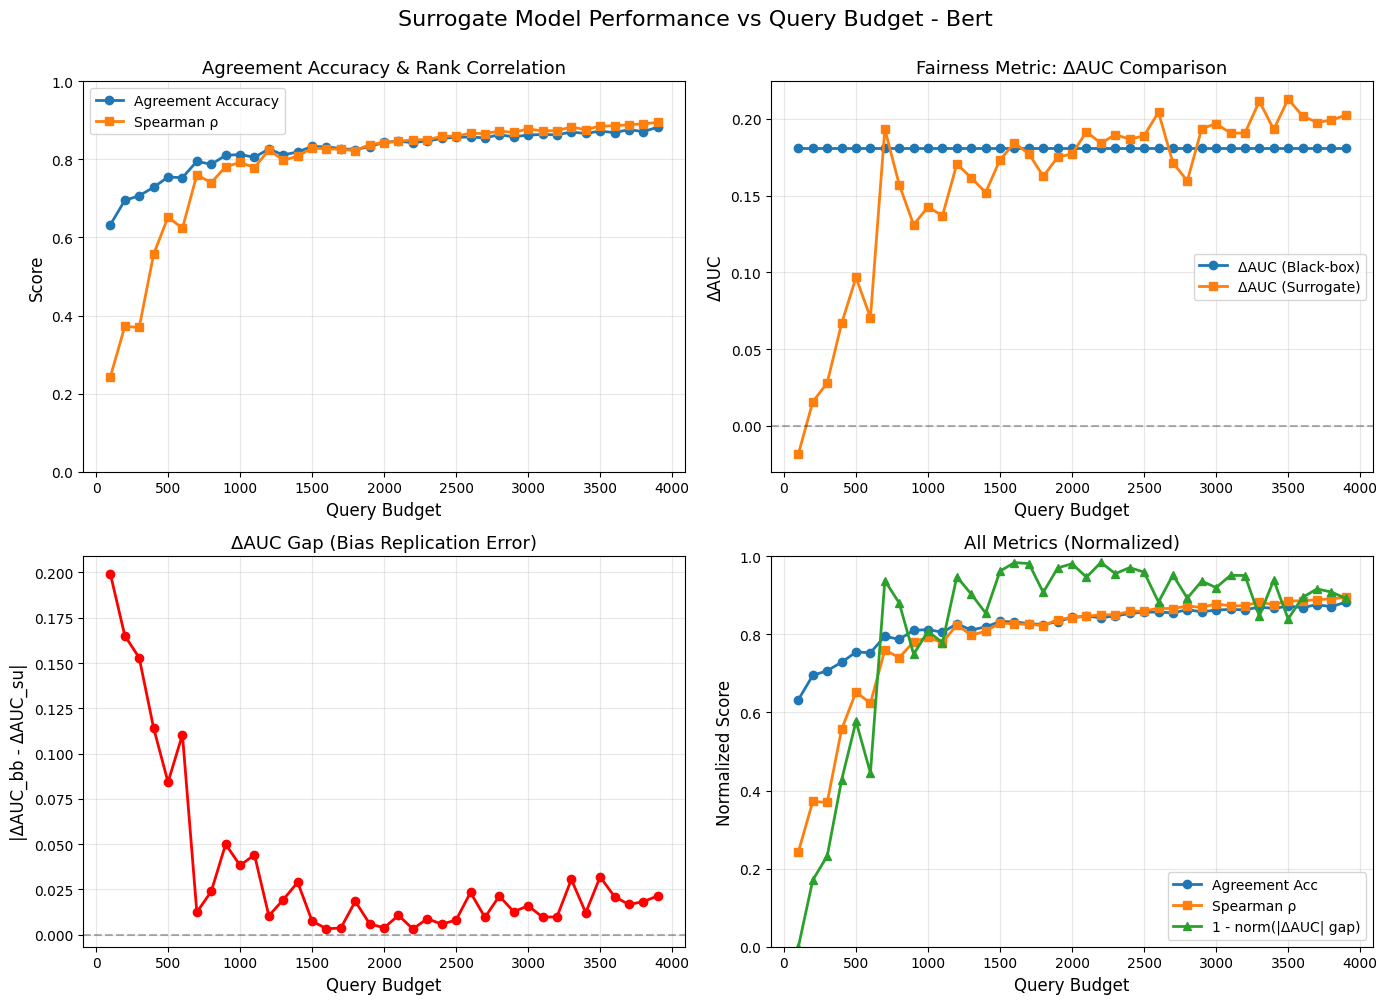

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data = np.array(data)
p_query = data[:, 0]
agree_acc = data[:, 1]
rank_rho = data[:, 2]
dAUC_bb = data[:, 3]
dAUC_su = data[:, 4]
auc_gap = data[:, 5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Surrogate Model Performance vs Query Budget - Bert', fontsize=16, y=1.00)

# 1. Agreement Accuracy and Rank Correlation
ax1 = axes[0, 0]
ax1.plot(p_query, agree_acc, 'o-', label='Agreement Accuracy', linewidth=2, markersize=6)
ax1.plot(p_query, rank_rho, 's-', label='Spearman ρ', linewidth=2, markersize=6)
ax1.set_xlabel('Query Budget', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Agreement Accuracy & Rank Correlation', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# 2. diff AUC Comparison (Black-box vs Surrogate)
ax2 = axes[0, 1]
ax2.plot(p_query, dAUC_bb, 'o-', label='ΔAUC (Black-box)', linewidth=2, markersize=6)
ax2.plot(p_query, dAUC_su, 's-', label='ΔAUC (Surrogate)', linewidth=2, markersize=6)
ax2.set_xlabel('Query Budget', fontsize=12)
ax2.set_ylabel('ΔAUC', fontsize=12)
ax2.set_title('Fairness Metric: ΔAUC Comparison', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# 3. diff AUC Gap (how well surrogate replicates bias)
ax3 = axes[1, 0]
ax3.plot(p_query, auc_gap, 'o-', color='red', linewidth=2, markersize=6)
ax3.set_xlabel('Query Budget', fontsize=12)
ax3.set_ylabel('|ΔAUC_bb - ΔAUC_su|', fontsize=12)
ax3.set_title('ΔAUC Gap (Bias Replication Error)', fontsize=13)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# 4. Combined view 
ax4 = axes[1, 1]

agree_norm = agree_acc
rank_norm = rank_rho
auc_gap_norm = 1 - auc_gap / auc_gap.max() if auc_gap.max() > 0 else auc_gap  # --> invert such that higher is better

ax4.plot(p_query, agree_norm, 'o-', label='Agreement Acc', linewidth=2, markersize=6)
ax4.plot(p_query, rank_norm, 's-', label='Spearman ρ', linewidth=2, markersize=6)
ax4.plot(p_query, auc_gap_norm, '^-', label='1 - norm(|ΔAUC| gap)', linewidth=2, markersize=6)
ax4.set_xlabel('Query Budget', fontsize=12)
ax4.set_ylabel('Normalized Score', fontsize=12)
ax4.set_title('All Metrics (Normalized)', fontsize=13)
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1])

plt.tight_layout()

plt.savefig('surrogate_performance_vs_budget.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data_hatebert = np.array(data_hatebert)
p_query = data_hatebert[:, 0]
agree_acc = data_hatebert[:, 1]
rank_rho = data_hatebert[:, 2]
dAUC_bb = data_hatebert[:, 3]
dAUC_su = data_hatebert[:, 4]
auc_gap = data_hatebert[:, 5]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Surrogate Model Performance vs Query Budget - HATEBert', fontsize=16, y=1.00)

# 1. Agreement Accuracy and Rank Correlation
ax1 = axes[0, 0]
ax1.plot(p_query, agree_acc, 'o-', label='Agreement Accuracy', linewidth=2, markersize=6)
ax1.plot(p_query, rank_rho, 's-', label='Spearman ρ', linewidth=2, markersize=6)
ax1.set_xlabel('Query Budget', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Agreement Accuracy & Rank Correlation', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 1])

# 2. diff AUC Comparison (Black-box vs Surrogate)
ax2 = axes[0, 1]
ax2.plot(p_query, dAUC_bb, 'o-', label='ΔAUC (Black-box)', linewidth=2, markersize=6)
ax2.plot(p_query, dAUC_su, 's-', label='ΔAUC (Surrogate)', linewidth=2, markersize=6)
ax2.set_xlabel('Query Budget', fontsize=12)
ax2.set_ylabel('ΔAUC', fontsize=12)
ax2.set_title('Fairness Metric: ΔAUC Comparison', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# 3. diff AUC Gap (how well surrogate replicates bias)
ax3 = axes[1, 0]
ax3.plot(p_query, auc_gap, 'o-', color='red', linewidth=2, markersize=6)
ax3.set_xlabel('Query Budget', fontsize=12)
ax3.set_ylabel('|ΔAUC_bb - ΔAUC_su|', fontsize=12)
ax3.set_title('ΔAUC Gap (Bias Replication Error)', fontsize=13)
ax3.grid(True, alpha=0.3)
ax3.axhline(y=0, color='k', linestyle='--', alpha=0.3)

# 4. Combined view 
ax4 = axes[1, 1]

agree_norm = agree_acc
rank_norm = rank_rho
auc_gap_norm = 1 - auc_gap / auc_gap.max() if auc_gap.max() > 0 else auc_gap  # --> invert such that higher is better

ax4.plot(p_query, agree_norm, 'o-', label='Agreement Acc', linewidth=2, markersize=6)
ax4.plot(p_query, rank_norm, 's-', label='Spearman ρ', linewidth=2, markersize=6)
ax4.plot(p_query, auc_gap_norm, '^-', label='1 - norm(|ΔAUC| gap)', linewidth=2, markersize=6)
ax4.set_xlabel('Query Budget', fontsize=12)
ax4.set_ylabel('Normalized Score', fontsize=12)
ax4.set_title('All Metrics (Normalized)', fontsize=13)
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('surrogate_performance_vs_budget.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'data_hatebert' is not defined

## BASELINES


Computing true ΔAUC on full dataset...
True ΔAUC (full dataset, 10000 samples): -0.179
Trial 1/30 (seed=22)...       n_queries  delta_auc  n_samples  seed
0            10        NaN         10    22
1            15        NaN         15    22
2            20        NaN         20    22
3            25        NaN         25    22
4            30        NaN         30    22
...         ...        ...        ...   ...
1994       9980  -0.178778       9980    22
1995       9985  -0.179372       9985    22
1996       9990  -0.179025       9990    22
1997       9995  -0.179275       9995    22
1998      10000  -0.179225      10000    22

[1999 rows x 4 columns]
      n_queries  delta_auc  n_samples  seed
0            10  -0.500000         10    22
1            15  -0.416667         15    22
2            20  -0.240000         20    22
3            25  -0.166667         25    22
4            30  -0.147321         30    22
...         ...        ...        ...   ...
1994       9980  -0.179365  

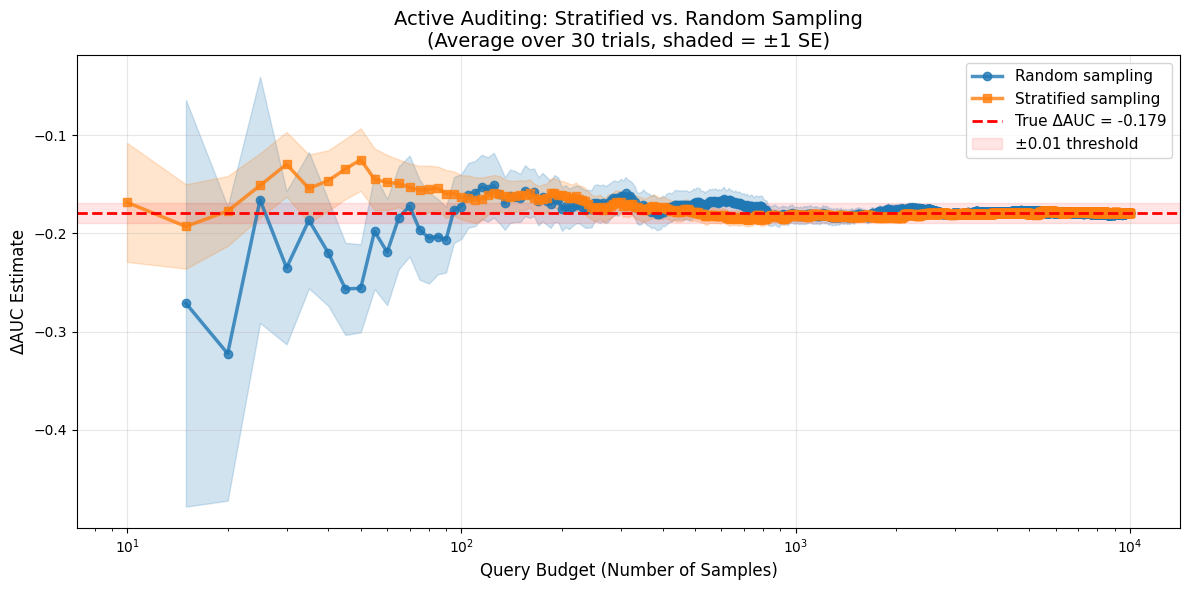


SUMMARY
Random      : Converged at   35 queries (0.4% of data) [std=0.277, SE=0.069]
Stratified  : Converged at   20 queries (0.2% of data) [std=0.195, SE=0.036]

Total dataset size: 10000
Number of trials: 30
True ΔAUC (full dataset): -0.179

Variance at full budget:
  Random:     std = 0.0000
  Stratified: std = 0.0000
  Reduction:  nan%


/tmp/ipykernel_64858/2701863970.py:212: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Reduction:  {(1 - final_stratified_std/final_random_std)*100:.1f}%")


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import warnings
import importlib, utils
importlib.reload(utils)



#  FAIRNESS METRIC: ΔAUC 

def compute_delta_auc(df, score_col='bb_score', group_col='group', ref_group=0, comp_group=1):
    """
    Compute ΔAUC = AUC(ref_group) - AUC(comp_group) between two groups.
    Handles invalid/missing data safely.
    """
    try:
        for c in (score_col, group_col, 'labels'):
            if c not in df.columns:
                warnings.warn(f"Column '{c}' not found in dataframe")
                return np.nan

        df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[score_col, 'labels', group_col])
        if len(df) < 10:
            return np.nan

        groups_present = set(df[group_col].unique().tolist())
        if not ({ref_group, comp_group} <= groups_present):
            warnings.warn(f"Groups {ref_group}, {comp_group} not both present")
            return np.nan

        def auc_for(g):
            sub = df[df[group_col] == g]
            if len(sub) < 4:
                return np.nan
            n_pos = (sub['labels'] == 1).sum()
            n_neg = (sub['labels'] == 0).sum()
            if n_pos < 2 or n_neg < 2:
                return np.nan
            return roc_auc_score(sub['labels'], sub[score_col])

        auc_ref = auc_for(ref_group)
        auc_cmp = auc_for(comp_group)
        if np.isnan(auc_ref) or np.isnan(auc_cmp):
            return np.nan
        if not (0 <= auc_ref <= 1 and 0 <= auc_cmp <= 1):
            return np.nan
        return float(auc_ref - auc_cmp)

    except Exception as e:
        warnings.warn(f"Error computing ΔAUC: {str(e)}")
        return np.nan


def rolling_delta_auc(ordered_df, scores, window_sizes, ref_group=0, comp_group=1):
    """
    Compute ΔAUC at increasing query budgets.
    """
    try:
        if len(ordered_df) != len(scores):
            raise ValueError(f"DataFrame length ({len(ordered_df)}) != scores length ({len(scores)})")
        if len(scores) == 0:
            raise ValueError("Empty scores array")

        df_with_scores = ordered_df.copy()
        df_with_scores['bb_score'] = scores

        results = []
        for n in window_sizes:
            if n > len(df_with_scores):
                break
            if n < 10:
                continue

            subset = df_with_scores.iloc[:n]
            delta = compute_delta_auc(subset, ref_group=ref_group, comp_group=comp_group)
            results.append({'n_queries': n, 'delta_auc': delta, 'n_samples': len(subset)})

        return pd.DataFrame(results)
    except Exception as e:
        warnings.warn(f"Error in rolling_delta_auc: {str(e)}")
        return pd.DataFrame(columns=['n_queries', 'delta_auc', 'n_samples'])


# 
#  MAIN TRIAL LOOP

def run_trial(D, api, window_sizes, seed, ref_group=0, comp_group=1):
    """Run one trial for both random and stratified sampling."""
    
    rand_D, rand_scores = utils.random_ordered_sampling(D, api.predict_scores, seed=seed)
    results_random = rolling_delta_auc(rand_D, rand_scores, window_sizes, ref_group, comp_group)
    results_random['seed'] = seed
    
    strat_D, strat_scores = utils.stratified_ordered_sampling(D, api.predict_scores, group_col='group',label_col='labels', group1=ref_group, group2=comp_group, seed = seed)
    results_stratified = rolling_delta_auc(strat_D, strat_scores, window_sizes, ref_group, comp_group)
    results_stratified['seed'] = seed

    return results_random, results_stratified


# === MAIN EXPERIMENT 

D["labels"] = D["true_label"]
max_queries = len(D)
window_sizes = list(range(5, max_queries + 1, 5))
ref_group, comp_group = 0, 1  # make this explicit!

# Compute true ΔAUC on full dataset
print("Computing true ΔAUC on full dataset...")
D_full_copy = D.copy()
D_full_copy['bb_score'] = api.predict_scores(D_full_copy["text"].tolist())
true_delta = compute_delta_auc(D_full_copy, ref_group=ref_group, comp_group=comp_group)
print(f"True ΔAUC (full dataset, {len(D)} samples): {true_delta:.3f}")
print("=" * 70)

# Run multiple trials
n_trials = 30
all_results_random, all_results_stratified = [], []

for trial in range(n_trials):
    seed = 22 + trial
    print(f"Trial {trial+1}/{n_trials} (seed={seed})...", end=" ")
    try:
        res_rand, res_strat = run_trial(D, api, window_sizes, seed, ref_group, comp_group)
        all_results_random.append(res_rand)
        all_results_stratified.append(res_strat)
        print(res_rand)
        print(res_strat)
        print("✓")
    except Exception as e:
        print(f"✗ Failed: {str(e)}")

print("=" * 70)

# Combine all trials
df_random_all = pd.concat(all_results_random, ignore_index=True)
df_stratified_all = pd.concat(all_results_stratified, ignore_index=True)

# Compute statistics
stats_random = df_random_all.groupby('n_queries')['delta_auc'].agg(['mean', 'std', 'count']).reset_index()
stats_stratified = df_stratified_all.groupby('n_queries')['delta_auc'].agg(['mean', 'std', 'count']).reset_index()
stats_random['se'] = stats_random['std'] / np.sqrt(stats_random['count'])
stats_stratified['se'] = stats_stratified['std'] / np.sqrt(stats_stratified['count'])


#  PLOT 


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(stats_random['n_queries'], stats_random['mean'],
        'o-', alpha=0.8, label='Random sampling', linewidth=2.5, color='C0')
ax.fill_between(stats_random['n_queries'],
                stats_random['mean'] - stats_random['se'],
                stats_random['mean'] + stats_random['se'], alpha=0.2, color='C0')

ax.plot(stats_stratified['n_queries'], stats_stratified['mean'],
        's-', alpha=0.8, label='Stratified sampling', linewidth=2.5, color='C1')
ax.fill_between(stats_stratified['n_queries'],
                stats_stratified['mean'] - stats_stratified['se'],
                stats_stratified['mean'] + stats_stratified['se'], alpha=0.2, color='C1')

ax.axhline(y=true_delta, color='red', linestyle='--',
           label=f'True ΔAUC = {true_delta:.3f}', linewidth=2)
ax.axhspan(true_delta - 0.01, true_delta + 0.01, alpha=0.1, color='red', label='±0.01 threshold')

ax.set_xscale('log')
ax.set_xlabel('Query Budget (Number of Samples)', fontsize=12)
ax.set_ylabel('ΔAUC Estimate', fontsize=12)
ax.set_title(f'Active Auditing: Stratified vs. Random Sampling\n(Average over {n_trials} trials, shaded = ±1 SE)',
             fontsize=14)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# === SUMMARY ===============================================
# ============================================================

print("\n" + "="*70)
print("SUMMARY")
print("="*70)

for df, name in [(stats_random, 'Random'), (stats_stratified, 'Stratified')]:
    df_copy = df.copy()
    df_copy['error'] = abs(df_copy['mean'] - true_delta)
    within_threshold = df_copy[df_copy['error'] < 0.01]

    if len(within_threshold) > 0:
        first_convergence = within_threshold.iloc[0]['n_queries']
        pct = first_convergence / max_queries * 100
        conv_std = within_threshold.iloc[0]['std']
        conv_se = within_threshold.iloc[0]['se']
        print(f"{name:12s}: Converged at {int(first_convergence):4d} queries "
              f"({pct:.1f}% of data) [std={conv_std:.3f}, SE={conv_se:.3f}]")
    else:
        print(f"{name:12s}: Did not converge within ±0.01")

print(f"\nTotal dataset size: {max_queries}")
print(f"Number of trials: {n_trials}")
print(f"True ΔAUC (full dataset): {true_delta:.3f}")
print("="*70)

final_random_std = stats_random.iloc[-1]['std']
final_stratified_std = stats_stratified.iloc[-1]['std']
print(f"\nVariance at full budget:")
print(f"  Random:     std = {final_random_std:.4f}")
print(f"  Stratified: std = {final_stratified_std:.4f}")
print(f"  Reduction:  {(1 - final_stratified_std/final_random_std)*100:.1f}%")
print("="*70)


stratified_ordered_sampling

In [37]:
def compute_summary_stats_over_time_baseline(
    df_all,
    true_delta
):
    """
    df_all: concatenated baseline results
            columns = ['seed', 'n_queries', 'delta_auc']
    """
    df = df_all.copy()
    df["error"] = np.abs(df["delta_auc"] - true_delta)

    grouped = (
        df.groupby("n_queries")["error"]
          .agg(
              mean="mean",
              std="std",
              median="median",
              n="count"
          )
          .reset_index()
          .sort_values("n_queries")
          .rename(columns={"n_queries": "T_size"})
    )

    return grouped


In [36]:
def per_seed_crossing_times_baseline(
    df_all,
    true_delta,
    epsilon
):
    rows = []

    for seed, seed_df in df_all.groupby("seed"):
        seed_df = seed_df.sort_values("n_queries").copy()
        seed_df["error"] = np.abs(seed_df["delta_auc"] - true_delta)

        crossed = seed_df[seed_df["error"] <= epsilon]
        T_hit = crossed.iloc[0]["n_queries"] if len(crossed) > 0 else None

        rows.append({
            "seed": seed,
            "T_hit": T_hit
        })

    return pd.DataFrame(rows)


In [35]:
def find_mean_crossing_time(summary_df, epsilon):
    crossed = summary_df[summary_df["mean"] <= epsilon]
    if len(crossed) == 0:
        return None
    return crossed.iloc[0]["T_size"]


In [34]:
def summarize_query_times(T_hits):
    times = np.array([t for t in T_hits if t is not None])

    if len(times) == 0:
        return {
            "mean_queries": None,
            "median_queries": None,
            "std_queries": None,
            "n_converged": 0
        }

    return {
        "mean_queries": times.mean(),
        "median_queries": np.median(times),
        "std_queries": times.std(ddof=1),
        "n_converged": len(times)
    }


In [33]:
def error_stats_at_T(summary_df, T_star):
    row = summary_df[summary_df["T_size"] == T_star]
    if len(row) == 0:
        return {
            "mean_error": None,
            "std_error": None,
            "median_error": None,
            "n": 0
        }

    row = row.iloc[0]
    return {
        "mean_error": row["mean"],
        "std_error": row["std"],
        "median_error": row["median"],
        "n": row["n"]
    }


In [32]:
def compute_full_epsilon_stats_baselines(
    baseline_dfs,          # dict: {"Random": df_random_all, "Stratified": df_stratified_all}
    true_delta,
    epsilon_values
):
    results = []

    for method_name, df_all in baseline_dfs.items():
        print(f"Processing {method_name}...", end=" ")

        summary_df = compute_summary_stats_over_time_baseline(
            df_all, true_delta
        )

        for epsilon in epsilon_values:
            # population-level crossing (mean-first)
            T_star = find_mean_crossing_time(summary_df, epsilon)

            # per-seed query times
            seed_hits = per_seed_crossing_times_baseline(
                df_all, true_delta, epsilon
            )
            query_stats = summarize_query_times(seed_hits["T_hit"])

            # error stats at crossing
            error_stats = (
                error_stats_at_T(summary_df, T_star)
                if T_star is not None else
                {"mean_error": None, "std_error": None, "median_error": None, "n": 0}
            )

            results.append({
                "strategy": method_name,
                "epsilon": epsilon,
                "mean_crossing_T": T_star,

                # query-level stats (per-seed)
                "mean_queries": query_stats["mean_queries"],
                "median_queries": query_stats["median_queries"],
                "std_queries": query_stats["std_queries"],
                "n_converged": query_stats["n_converged"],

                # error-level stats (mean curve)
                "mean_error": error_stats["mean_error"],
                "std_error": error_stats["std_error"],
                "median_error": error_stats["median_error"],
                "n_at_T": error_stats["n"],
            })

        print("✓")

    return pd.DataFrame(results)


In [38]:
baseline_stats = compute_full_epsilon_stats_baselines(
    baseline_dfs={
        "Random": df_random_all,
        "Stratified": df_stratified_all,
    },
    true_delta=true_delta,
    epsilon_values=[0.02, 0.05]
)

baseline_stats


Processing Random... ✓
Processing Stratified... ✓


,strategy,epsilon,mean_crossing_T,mean_queries,median_queries,std_queries,n_converged,mean_error,std_error,median_error,n_at_T
0,Random,0.02,2815.0,584.000000,145.0,1300.844156,30,0.019711,0.015332,0.014492,30.0
1,Random,0.05,585.0,252.833333,85.0,477.258123,30,0.049499,0.046322,0.036345,30.0
2,Stratified,0.02,1095.0,189.666667,67.5,304.616586,30,0.019750,0.015480,0.016588,30.0
3,Stratified,0.05,305.0,102.333333,30.0,201.326349,30,0.049919,0.034658,0.048574,30.0


In [39]:
import numpy as np
import pandas as pd
from typing import Dict, List, Optional

# ============================================
# YOUR EXISTING FUNCTIONS (UNCHANGED)
# ============================================

def compute_summary_stats_over_time_baseline(
    df_all,
    true_delta
):
    """
    df_all: concatenated baseline results
            columns = ['seed', 'n_queries', 'delta_auc']
    """
    df = df_all.copy()
    df["error"] = np.abs(df["delta_auc"] - true_delta)
    grouped = (
        df.groupby("n_queries")["error"]
          .agg(
              mean="mean",
              std="std",
              median="median",
              n="count"
          )
          .reset_index()
          .sort_values("n_queries")
          .rename(columns={"n_queries": "T_size"})
    )
    return grouped


def per_seed_crossing_times_baseline(
    df_all,
    true_delta,
    epsilon
):
    rows = []
    for seed, seed_df in df_all.groupby("seed"):
        seed_df = seed_df.sort_values("n_queries").copy()
        seed_df["error"] = np.abs(seed_df["delta_auc"] - true_delta)
        crossed = seed_df[seed_df["error"] <= epsilon]
        T_hit = crossed.iloc[0]["n_queries"] if len(crossed) > 0 else None
        rows.append({
            "seed": seed,
            "T_hit": T_hit
        })
    return pd.DataFrame(rows)


def find_mean_crossing_time(summary_df, epsilon):
    """Find first T where mean error <= epsilon"""
    crossed = summary_df[summary_df["mean"] <= epsilon]
    if len(crossed) == 0:
        return None
    return crossed.iloc[0]["T_size"]


def summarize_query_times(T_hits):
    times = np.array([t for t in T_hits if t is not None])
    if len(times) == 0:
        return {
            "mean_queries": None,
            "median_queries": None,
            "std_queries": None,
            "n_converged": 0
        }
    return {
        "mean_queries": times.mean(),
        "median_queries": np.median(times),
        "std_queries": times.std(ddof=1),
        "n_converged": len(times)
    }


def error_stats_at_T(summary_df, T_star):
    row = summary_df[summary_df["T_size"] == T_star]
    if len(row) == 0:
        return {
            "mean_error": None,
            "std_error": None,
            "median_error": None,
            "n": 0
        }
    row = row.iloc[0]
    return {
        "mean_error": row["mean"],
        "std_error": row["std"],
        "median_error": row["median"],
        "n": row["n"]
    }


# ============================================
# NEW: BOOTSTRAP FUNCTIONS
# ============================================

def bootstrap_mean_crossing_T(
    df_all,
    true_delta,
    epsilon,
    n_bootstrap=1000,
    ci_level=0.95,
    random_state=42
):
    """
    Bootstrap confidence interval for mean_crossing_T.
    
    Parameters:
    -----------
    df_all : DataFrame
        Baseline results with columns ['seed', 'n_queries', 'delta_auc']
    true_delta : float
        Ground truth fairness metric
    epsilon : float
        Convergence threshold
    n_bootstrap : int
        Number of bootstrap samples
    ci_level : float
        Confidence interval level (default: 0.95)
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    dict with keys: mean, median, ci_lower, ci_upper, n_converged, bootstrap_samples
    """
    np.random.seed(random_state)
    
    # Get unique seeds
    seeds = df_all['seed'].unique()
    n_seeds = len(seeds)
    
    if n_seeds < 3:
        return {
            'mean': None,
            'median': None,
            'ci_lower': None,
            'ci_upper': None,
            'n_converged': 0,
            'bootstrap_samples': []
        }
    
    crossing_Ts = []
    
    for i in range(n_bootstrap):
        # Resample seeds with replacement
        boot_seeds = np.random.choice(seeds, size=n_seeds, replace=True)
        
        # Get data for bootstrapped seeds
        boot_df = df_all[df_all['seed'].isin(boot_seeds)].copy()
        
        # Compute mean curve for this bootstrap sample
        boot_df["error"] = np.abs(boot_df["delta_auc"] - true_delta)
        boot_summary = (
            boot_df.groupby("n_queries")["error"]
                   .mean()
                   .reset_index()
                   .sort_values("n_queries")
                   .rename(columns={"n_queries": "T_size", "error": "mean"})
        )
        
        # Find crossing time
        T_cross = find_mean_crossing_time(boot_summary, epsilon)
        
        if T_cross is not None:
            crossing_Ts.append(T_cross)
    
    if len(crossing_Ts) == 0:
        return {
            'mean': None,
            'median': None,
            'ci_lower': None,
            'ci_upper': None,
            'n_converged': 0,
            'bootstrap_samples': []
        }
    
    crossing_Ts = np.array(crossing_Ts)
    alpha = 1 - ci_level
    
    return {
        'mean': np.mean(crossing_Ts),
        'median': np.median(crossing_Ts),
        'ci_lower': np.percentile(crossing_Ts, 100 * alpha / 2),
        'ci_upper': np.percentile(crossing_Ts, 100 * (1 - alpha / 2)),
        'n_converged': len(crossing_Ts),
        'bootstrap_samples': crossing_Ts.tolist()
    }


# ============================================
# UPDATED: MAIN COMPUTATION WITH BOOTSTRAP
# ============================================

def compute_full_epsilon_stats_baselines(
    baseline_dfs,          # dict: {"Random": df_random_all, "Stratified": df_stratified_all}
    true_delta,
    epsilon_values,
    n_bootstrap=1000,      # NEW parameter
    ci_level=0.95,         # NEW parameter
    random_state=42        # NEW parameter
):
    """
    Compute convergence statistics with bootstrap confidence intervals.
    """
    results = []
    
    for method_name, df_all in baseline_dfs.items():
        print(f"Processing {method_name}...", end=" ")
        
        # Compute summary statistics
        summary_df = compute_summary_stats_over_time_baseline(
            df_all, true_delta
        )
        
        for epsilon in epsilon_values:
            # 1. Population-level crossing (mean-first)
            T_star = find_mean_crossing_time(summary_df, epsilon)
            
            # 2. Bootstrap CI for mean_crossing_T
            boot_stats = bootstrap_mean_crossing_T(
                df_all, true_delta, epsilon, 
                n_bootstrap=n_bootstrap,
                ci_level=ci_level,
                random_state=random_state
            )
            
            # 3. Per-seed query times
            seed_hits = per_seed_crossing_times_baseline(
                df_all, true_delta, epsilon
            )
            query_stats = summarize_query_times(seed_hits["T_hit"])
            
            # 4. Error stats at crossing
            error_stats = (
                error_stats_at_T(summary_df, T_star)
                if T_star is not None else
                {"mean_error": None, "std_error": None, "median_error": None, "n": 0}
            )
            
            results.append({
                "strategy": method_name,
                "epsilon": epsilon,
                
                # Population-level convergence
                "mean_crossing_T": T_star,
                "mean_crossing_T_boot_mean": boot_stats['mean'],
                "mean_crossing_T_boot_median": boot_stats['median'],
                "mean_crossing_T_ci_lower": boot_stats['ci_lower'],
                "mean_crossing_T_ci_upper": boot_stats['ci_upper'],
                "mean_crossing_T_boot_converged": boot_stats['n_converged'],
                
                # Per-seed query-level stats
                "mean_queries": query_stats["mean_queries"],
                "median_queries": query_stats["median_queries"],
                "std_queries": query_stats["std_queries"],
                "n_converged": query_stats["n_converged"],
                
                # Error-level stats at crossing
                "mean_error": error_stats["mean_error"],
                "std_error": error_stats["std_error"],
                "median_error": error_stats["median_error"],
                "n_at_T": error_stats["n"],
            })
        
        print("✓")
    
    return pd.DataFrame(results)


# ============================================
# RUN YOUR ANALYSIS (WITH BOOTSTRAP)
# ============================================

baseline_stats = compute_full_epsilon_stats_baselines(
    baseline_dfs={
        "Random": df_random_all,
        "Stratified": df_stratified_all,
    },
    true_delta=true_delta,
    epsilon_values=[0.02, 0.05],
    n_bootstrap=1000,      # 1000 bootstrap samples
    ci_level=0.95,         # 95% CI
    random_state=42        # for reproducibility
)

display(baseline_stats)

Processing Random... ✓
Processing Stratified... ✓


,strategy,epsilon,mean_crossing_T,mean_crossing_T_boot_mean,mean_crossing_T_boot_median,mean_crossing_T_ci_lower,mean_crossing_T_ci_upper,mean_crossing_T_boot_converged,mean_queries,median_queries,std_queries,n_converged,mean_error,std_error,median_error,n_at_T
0,Random,0.02,2815.0,2397.255,2555.0,1525.0,3350.25,1000,584.000000,145.0,1300.844156,30,0.019711,0.015332,0.014492,30.0
1,Random,0.05,585.0,618.730,585.0,425.0,825.00,1000,252.833333,85.0,477.258123,30,0.049499,0.046322,0.036345,30.0
2,Stratified,0.02,1095.0,1125.960,1090.0,1005.0,1515.00,1000,189.666667,67.5,304.616586,30,0.019750,0.015480,0.016588,30.0
3,Stratified,0.05,305.0,319.200,282.5,175.0,450.25,1000,102.333333,30.0,201.326349,30,0.049919,0.034658,0.048574,30.0


Minority group proportion: π_min = 0.360


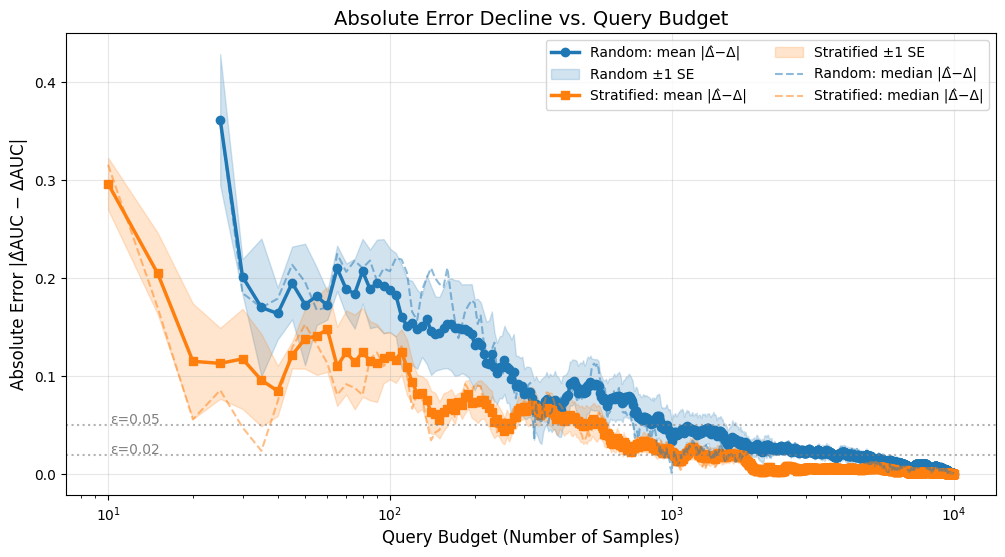

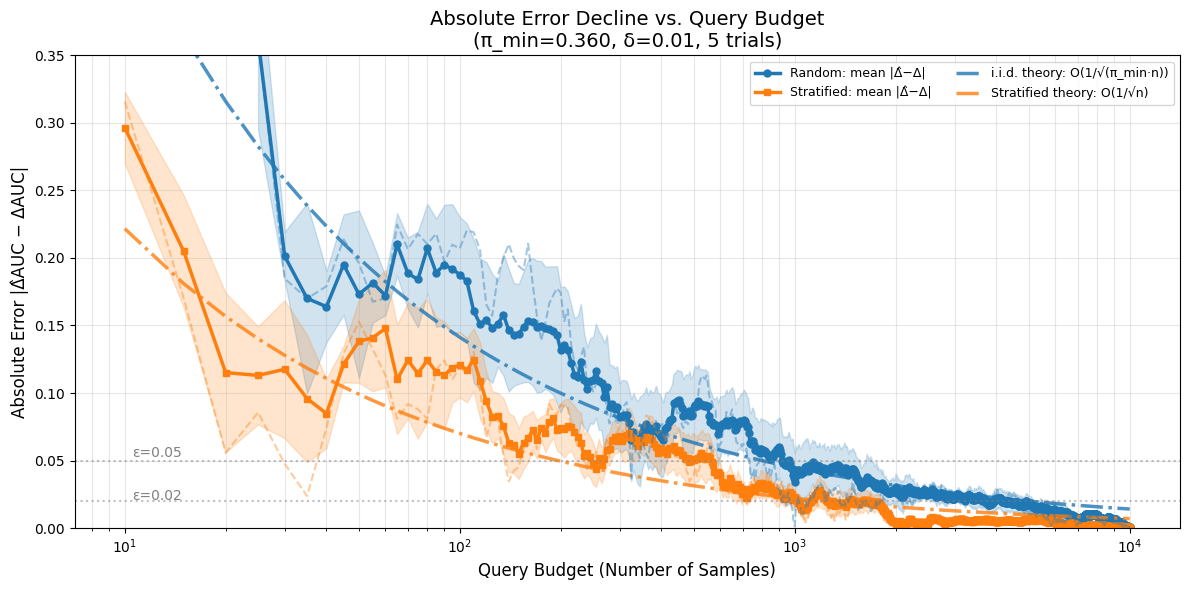

In [ ]:

def aggregate_abs_error(df_all, true_delta):
    """
    Expects columns: ['n_queries','delta_auc'] (+ 'seed' optional).
    Returns per-budget stats of |delta_auc - true_delta|.
    """
    df = df_all.copy()
    df['abs_err'] = (df['delta_auc'] - true_delta).abs()
    stats = (df.groupby('n_queries')['abs_err']
               .agg(['mean','std','count','median'])
               .reset_index())
    stats['se'] = stats['std'] / np.sqrt(stats['count'])
    return stats

mae_random = aggregate_abs_error(df_random_all, true_delta)
mae_strat  = aggregate_abs_error(df_stratified_all, true_delta)

# small epsilon to make bands visible if se==0
eps_band = 1e-6
se_rand  = np.maximum(mae_random['se'].to_numpy(), eps_band)
se_strat = np.maximum(mae_strat['se'].to_numpy(),  eps_band)

# PLOT: Absolute error decline 
fig, ax = plt.subplots(figsize=(12, 6))

# Random (blue)
ax.plot(mae_random['n_queries'], mae_random['mean'],
        'o-', linewidth=2.5, label='Random: mean |Δ̂−Δ|', color='C0')
ax.fill_between(mae_random['n_queries'],
                mae_random['mean'] - se_rand,
                mae_random['mean'] + se_rand,
                alpha=0.2, color='C0', label='Random ±1 SE')

# Stratified (orange)
ax.plot(mae_strat['n_queries'], mae_strat['mean'],
        's-', linewidth=2.5, label='Stratified: mean |Δ̂−Δ|', color='C1')
ax.fill_between(mae_strat['n_queries'],
                mae_strat['mean'] - se_strat,
                mae_strat['mean'] + se_strat,
                alpha=0.2, color='C1', label='Stratified ±1 SE')

ax.plot(mae_random['n_queries'], mae_random['median'],
        '--', alpha=0.5, color='C0', linewidth=1.5, label='Random: median |Δ̂−Δ|')
ax.plot(mae_strat['n_queries'], mae_strat['median'],
        '--', alpha=0.5, color='C1', linewidth=1.5, label='Stratified: median |Δ̂−Δ|')

for eps in [0.05, 0.02]:
    ax.axhline(eps, color='grey', linestyle=':', alpha=0.6)
    ax.text(mae_random['n_queries'].min()*1.02, eps*1.02, f'ε={eps}', color='grey')

ax.set_xscale('log')
ax.set_xlabel('Query Budget (Number of Samples)', fontsize=12)
ax.set_ylabel('Absolute Error |Δ̂AUC − ΔAUC|', fontsize=12)
ax.set_title('Absolute Error Decline vs. Query Budget', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, ncol=2)
# --> THEORY OVERLAY
def theory_eps(n, delta=0.05, K=2.0, scale=1.0, max_error=1.0):
    """
    Concentration bound: epsilon(n) = sqrt( K * log(4/delta) / (scale * n) )
    Capped at max_error since |Δ̂AUC - ΔAUC| ≤ 1.0
    
    Args:
        n: sample size
        delta: confidence parameter (probability of exceeding bound)
        K: constant from concentration inequality
        scale: scaling factor (e.g., 1/pi_min for i.i.d. sampling)
        max_error: maximum possible error (1.0 for ΔAUC)
    """
    n = np.asarray(n, dtype=float)
    eps = np.sqrt(K * np.log(4.0 / delta) / (scale * np.maximum(n, 1.0)))
    return np.minimum(eps, max_error)  # Cap at maximum possible error

# Compute pi_min from your dataset (minority group share)
pi_counts = D['group'].value_counts(normalize=True)
pi_min = float(pi_counts.min())

print(f"Minority group proportion: π_min = {pi_min:.3f}")

# tune this!
delta_theory = 0.01  # 99% confidence
K_strat = 0.082   # Constant from concentration inequality for stratified
K_iid   = 0.12   # Same order; i.i.d. differs by the 1/pi_min factor in scale

# X-axis points for theory curves (align to your budgets)
n_grid = np.array(sorted(set(mae_random['n_queries']).union(set(mae_strat['n_queries'])))) \
         if isinstance(mae_random, pd.DataFrame) else mae_random['n_queries'].to_numpy()

# Curves (now capped at 1.0)
eps_strat_theory = theory_eps(n_grid, delta=delta_theory, K=K_strat, scale=1.0, max_error=1.0)
eps_iid_theory   = theory_eps(n_grid, delta=delta_theory, K=K_iid,   scale=pi_min, max_error=1.0)

# Optional: theory bands to reflect constant uncertainty
K_low, K_high = 0.01, 1  # Reasonable range for concentration constants
band_strat_lo = theory_eps(n_grid, delta=delta_theory, K=K_low,  scale=1.0, max_error=1.0)
band_strat_hi = theory_eps(n_grid, delta=delta_theory, K=K_high, scale=1.0, max_error=1.0)
band_iid_lo   = theory_eps(n_grid, delta=delta_theory, K=K_low,  scale=pi_min, max_error=1.0)
band_iid_hi   = theory_eps(n_grid, delta=delta_theory, K=K_high, scale=pi_min, max_error=1.0)

# === PLOT OVER EXISTING ABS-ERROR FIG ========================================
fig, ax = plt.subplots(figsize=(12, 6))

# Random (blue)
ax.plot(mae_random['n_queries'], mae_random['mean'],
        'o-', linewidth=2.5, label='Random: mean |Δ̂−Δ|', color='C0', markersize=5)
ax.fill_between(mae_random['n_queries'],
                mae_random['mean'] - se_rand,
                mae_random['mean'] + se_rand,
                alpha=0.2, color='C0')

# Stratified (orange)
ax.plot(mae_strat['n_queries'], mae_strat['mean'],
        's-', linewidth=2.5, label='Stratified: mean |Δ̂−Δ|', color='C1', markersize=5)
ax.fill_between(mae_strat['n_queries'],
                mae_strat['mean'] - se_strat,
                mae_strat['mean'] + se_strat,
                alpha=0.2, color='C1')

# Theory curves
ax.plot(n_grid, eps_iid_theory,   '-.', linewidth=2.5, color='C0', 
        label=f'i.i.d. theory: O(1/√(π_min·n))', alpha=0.8)
ax.plot(n_grid, eps_strat_theory, '-.', linewidth=2.5, color='C1', 
        label='Stratified theory: O(1/√n)', alpha=0.8)
'''
# Light bands showing uncertainty in constants
ax.fill_between(n_grid, band_iid_lo, band_iid_hi,   
                color='C0', alpha=0.08, label='i.i.d. theory band')
ax.fill_between(n_grid, band_strat_lo, band_strat_hi, 
                color='C1', alpha=0.08, label='Stratified theory band')
'''
# Optional: show median as faint lines (robust to outliers)
ax.plot(mae_random['n_queries'], mae_random['median'],
        '--', alpha=0.4, color='C0', linewidth=1.5)
ax.plot(mae_strat['n_queries'], mae_strat['median'],
        '--', alpha=0.4, color='C1', linewidth=1.5)

# Reference error thresholds
for eps, label in [(0.05, 'ε=0.05'), (0.02, 'ε=0.02')]:
    ax.axhline(eps, color='grey', linestyle=':', alpha=0.5, linewidth=1.5)
    ax.text(n_grid.min()*1.05, eps*1.05, label, color='grey', fontsize=10)

# Formatting
ax.set_xscale('log')
  # Log scale makes O(1/√n) behavior linear!
ax.set_xlabel('Query Budget (Number of Samples)', fontsize=12)
ax.set_ylabel('Absolute Error |Δ̂AUC − ΔAUC|', fontsize=12)
ax.set_title(f'Absolute Error Decline vs. Query Budget\n(π_min={pi_min:.3f}, δ={delta_theory}, {n_trials} trials)', 
             fontsize=14)

ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=9, ncol=2, loc='upper right')
ax.set_ylim(0,0.35)

plt.tight_layout()
plt.show()



## Simple Active Audit

In [ ]:
def train_surrogate(base_model, tokenizer, df_S_train, epochs_sur = 20, batch_size = 64):
   
    # Train surrogate on S
    surrogate = surrogate_model.train_surrogate(
        base_model, tokenizer, df_S_train, epochs_sur, batch_size
    )
    # Usage
    # Handle both float and list formats
    if isinstance(S["bb_score"].iloc[0], (list, np.ndarray)):
        series_float = S["bb_score"].apply(lambda x: x[0])
    else:
        series_float = S["bb_score"]
    
    calibration_data = list(zip(S["text"], series_float))

    surrogate = calibrate_surrogate(surrogate, calibration_data, tokenizer)
    

    return surrogate

In [ ]:
def evaluate_surrogate(surrogate, df_D_mapped, bb):
    X = df_D_mapped["text"]
    y = np.array(df_D_mapped["labels"])
    a = np.array(df_D_mapped["group"])
    bb = api.predict_scores(X)            # shape (n,) in [0,1]
    su = calibrated_predict_batched(surrogate, X, tokenizer, batch_size=128)    

    agree_acc = ((bb > 0.5) == (su > 0.5)).mean()
    rank_rho = spearmanr(bb, su).correlation
    auc_bb_0, auc_bb_1 = roc_auc_score(y[a==0], bb[a==0]), roc_auc_score(y[a==1], bb[a==1])
    auc_su_0, auc_su_1 = roc_auc_score(y[a==0], su[a==0]), roc_auc_score(y[a==1], su[a==1])
    dAUC_bb, dAUC_su = auc_bb_0 - auc_bb_1, auc_su_0 - auc_su_1
    print(f"AgreeAcc={agree_acc:.3f} | Spearman={rank_rho:.3f} | ΔAUC_bb={dAUC_bb:.3f} | ΔAUC_su={dAUC_su:.3f} | |Δ| gap={abs(dAUC_bb-dAUC_su):.3f}")
    surrogate_data = [agree_acc, rank_rho, dAUC_bb, dAUC_su, abs(dAUC_bb-dAUC_su)]
    return surrogate_data

In [ ]:
def get_bert_embeddings(surrogate, texts, tokenizer, batch_size=128):
    surrogate.eval()
    all_emb = []
    for i in range(0, len(texts), batch_size):
        encoded = tokenizer(texts[i:i+batch_size], padding=True, truncation=True, max_length=512, return_tensors='pt')
        encoded = {k: v.to(surrogate.device) for k, v in encoded.items()}
        with torch.no_grad():
            outputs = surrogate(**encoded, output_hidden_states=True)
            all_emb.append(outputs.hidden_states[-1][:, 0, :].cpu().numpy())  # [CLS] token
    return np.vstack(all_emb)

In [ ]:

import numpy as np
from collections import defaultdict



def kcenter_diversity(emb, chosen_idx, cand_idx, api):
    # Distance from candidate to nearest chosen (cosine -> use 1 - dot)
    if len(chosen_idx) == 0: return np.ones(len(cand_idx))
    C = emb[chosen_idx] @ emb[cand_idx].T  # cosine sims
    return 1.0 - C.max(axis=0)  # higher = more diverse


def simple_active_round(pool_texts, pool_groups, labeled_idx, unlabeled_idx,
                        surrogate, batch_size=64):
    """Simplified active auditing: uncertainty + diversity + balance"""
    unl_list = list(unlabeled_idx)
    
    # 1) Uncertainty
    mu_u = calibrated_predict_batched(surrogate, pool_texts, tokenizer, batch_size=128)
    var_u = mu_u * (1 - mu_u)
    std_u = np.sqrt(np.maximum(var_u, 1e-6))
    
    # 2) Diversity
    emb = get_bert_embeddings(surrogate, pool_texts, tokenizer)
    if len(labeled_idx) > 0:
        labeled_texts = [D['text'][list(D['id']).index(id_val)] for id_val in labeled_idx]
        emb_labeled = get_bert_embeddings(surrogate, labeled_texts, tokenizer)
        emb_labeled_norm = emb_labeled / (np.linalg.norm(emb_labeled, axis=1, keepdims=True) + 1e-8)
        emb_unl_norm = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-8)
        dists = 1.0 - (emb_labeled_norm @ emb_unl_norm.T).max(axis=0)
    else:
        dists = np.ones(len(pool_texts))
    
    # 3) Group balancing
    labeled_groups = np.array([D['group'][list(D['id']).index(id_val)] for id_val in labeled_idx])
    g_counts = {g: (labeled_groups == g).sum() if len(labeled_groups) > 0 else 0 for g in [0,1]}
    minority_g = 0 if g_counts[0] <= g_counts[1] else 1
    group_boost = np.array([2.0 if pool_groups[i] == minority_g else 1.0 
                            for i in range(len(pool_texts))])
    
    # 4) Acquisition
    acq = std_u * dists * group_boost
    
    # 5) Select top-k (indices into pool_texts)
    top_k = np.argsort(-acq)[:batch_size]
    picked_idx = [unl_list[i] for i in top_k]  # Map back to D IDs
    
    # 6) Query
    new_labeled_idx = labeled_idx | set(picked_idx)
    
    return new_labeled_idx, picked_idx



In [ ]:
def rolling_delta_auc(ordered_df, scores, window_sizes, ref_group=0, comp_group=1):
    """
    Compute ΔAUC at increasing query budgets.
    
    Args:
        ordered_df: DataFrame with samples in the order they were queried
        scores: List/array of BB scores in the same order
        window_sizes: List of query budgets to evaluate
        ref_group: Reference group index
        comp_group: Comparison group index
    
    Returns:
        DataFrame with columns: n_queries, delta_auc, n_samples
    """
    try:
        if len(ordered_df) != len(scores):
            raise ValueError(f"DataFrame length ({len(ordered_df)}) != scores length ({len(scores)})")
        if len(scores) == 0:
            raise ValueError("Empty scores array")
        
        df_with_scores = ordered_df.copy()
        df_with_scores['bb_score'] = scores
        
        results = []
        for n in window_sizes:
            if n > len(df_with_scores):
                break
            if n < 10:  # Minimum samples for meaningful AUC
                continue
            
            subset = df_with_scores.iloc[:n]
            delta = compute_delta_auc(subset, ref_group=ref_group, comp_group=comp_group)
            results.append({
                'n_queries': n, 
                'delta_auc': delta, 
                'n_samples': len(subset)
            })
        
        return pd.DataFrame(results)
    
    except Exception as e:
        warnings.warn(f"Error in rolling_delta_auc: {str(e)}")
        return pd.DataFrame(columns=['n_queries', 'delta_auc', 'n_samples'])

In [ ]:
mae_strat

,n_queries,mean,std,count,median,se
0,10,0.296487,0.059160,5,0.315771,0.026457
1,15,0.204821,0.092758,5,0.169937,0.041483
2,20,0.115154,0.131838,5,0.055771,0.058960
3,25,0.113036,0.080961,5,0.085612,0.036207
4,30,0.117617,0.114188,5,0.047750,0.051067
...,...,...,...,...,...,...
1994,9980,0.000120,0.000054,5,0.000109,0.000024
1995,9985,0.000102,0.000028,5,0.000093,0.000013
1996,9990,0.000101,0.000059,5,0.000098,0.000026
1997,9995,0.000068,0.000040,5,0.000066,0.000018


In [ ]:
import pandas as pd
import warnings
from typing import List, Set

# Prepare data
D["labels"] = D["true_label"]
max_queries = len(D)
window_sizes = list(range(5, max_queries + 1, 5))
ref_group, comp_group = 0, 1  # make this explicit!

# Compute true ΔAUC on full dataset
print("Computing true ΔAUC on full dataset...")
D_full_copy = D.copy()
D_full_copy['bb_score'] = api.predict_scores(D_full_copy["text"].tolist())
true_delta = compute_delta_auc(D_full_copy, ref_group=ref_group, comp_group=comp_group)
print(f"True ΔAUC (full dataset, {len(D)} samples): {true_delta:.3f}")
print("=" * 70)

# Map the full D once
D, df_D_mapped = df_map(dataset_D, tokenizer, False)
df_D_mapped = df_D_mapped  # promote to member
inputs_D = {
    "input_ids": torch.tensor(df_D_mapped["input_ids"]).long(),
    "attention_mask": torch.tensor(df_D_mapped["attention_mask"]).long(),
    "labels": torch.tensor(df_D_mapped["labels"]).long(),
    "id": df_D_mapped["id"],
}

tokenizer, base_model = surrogate_model.load_lora_bert_surrogate(model_name = "GroNLP/hateBERT")

# Seed S
S = initialize_dataset_S(200, D, api)
labeled_idx = set(S['id'])
unlabeled_idx = set(df_D_mapped['id']) - labeled_idx

df_S, df_S_mapped = df_map(S, tokenizer, True)
needed = ["input_ids", "attention_mask", "labels", "bb_score"]
if "token_type_ids" in df_S_mapped.column_names:
    needed.append("token_type_ids")
df_S_train = df_S_mapped.remove_columns(
    [c for c in df_S_mapped.column_names if c not in needed]
).with_format("torch", columns=needed)

surrogate = train_surrogate(base_model, tokenizer, df_S_train, epochs_sur=20, batch_size=64)
eval_data = evaluate_surrogate(surrogate, df_D_mapped, api)

# Initialize tracking structures
pool_texts = [text for i, text in enumerate(D['text']) if D['id'][i] in unlabeled_idx]
pool_groups = D['group']
ordered_samples = []  # Track the order samples were queried
ordered_scores = []   # Track their corresponding BB scores
all_delta_auc_results = []  # Store ΔAUC at each window

# Active learning loop
iteration = 0
batch_size = 64

while len(labeled_idx) <800:
    iteration += 1
    print(f"\n{'='*70}")
    print(f"Iteration {iteration}: Labeled={len(labeled_idx)}, Unlabeled={len(unlabeled_idx)}")
    
    new_labeled_idx, picked_idx = simple_active_round(
    pool_texts, pool_groups, labeled_idx, unlabeled_idx, surrogate, batch_size
)

    # Get the newly added samples
    newly_added_ids = new_labeled_idx - labeled_idx

    # Query BB scores for newly added samples
    newly_added_list = list(newly_added_ids)
    newly_added_texts = [D[D['id'] == new_id].iloc[0]['text'] for new_id in newly_added_list]
    bb_scores = api.predict_scores(newly_added_texts)

    # Track the ordered samples and their scores
    for idx, new_id in enumerate(newly_added_list):
        sample_row = D[D['id'] == new_id].iloc[0]
        ordered_samples.append(sample_row)
        ordered_scores.append(bb_scores[idx])

    # Update labeled/unlabeled sets
    labeled_idx = new_labeled_idx
    unlabeled_idx = set(df_D_mapped['id']) - labeled_idx

    # Update S with ALL labeled samples and their BB scores
    S = D[D['id'].isin(labeled_idx)].copy()
    S['bb_score'] = api.predict_scores(S['text'].tolist())

    # Compute rolling ΔAUC at current query budget
    if len(ordered_samples) >= 10:
        ordered_df = pd.DataFrame(ordered_samples)
        delta_auc_df = rolling_delta_auc(
            ordered_df, ordered_scores, 
            window_sizes=[len(ordered_samples)],
            ref_group=ref_group, comp_group=comp_group
        )
        if not delta_auc_df.empty:
            current_delta = delta_auc_df.iloc[0]['delta_auc']
            all_delta_auc_results.append({
                'iteration': iteration,
                'n_queries': len(ordered_samples),
                'delta_auc': current_delta,
                'true_delta_auc': true_delta
            })
            print(f"Current ΔAUC (n={len(ordered_samples)}): {current_delta:.3f} "
                f"(True: {true_delta:.3f}, Error: {abs(current_delta - true_delta):.3f})")
    
    # Update pool for next iteration
    pool_texts = [text for i, text in enumerate(D['text']) if D['id'][i] in unlabeled_idx]
    
    # Retrain surrogate periodically (e.g., every few iterations)
  
    df_S, df_S_mapped = df_map(S, tokenizer, True)
    df_S_train = df_S_mapped.remove_columns(
        [c for c in df_S_mapped.column_names if c not in needed]
    ).with_format("torch", columns=needed)
    surrogate = train_surrogate(surrogate, tokenizer, df_S_train, epochs_sur=20, batch_size=64)

# Final comprehensive ΔAUC analysis across all window sizes
print(f"\n{'='*70}")
print("Final rolling ΔAUC analysis across all window sizes...")
ordered_df = pd.DataFrame(ordered_samples)
final_delta_auc_df = rolling_delta_auc(
    ordered_df, 
    ordered_scores, 
    window_sizes=window_sizes,
    ref_group=ref_group, 
    comp_group=comp_group
)

# Add true ΔAUC for comparison
final_delta_auc_df['true_delta_auc'] = true_delta
final_delta_auc_df['error'] = abs(final_delta_auc_df['delta_auc'] - true_delta)

print(final_delta_auc_df.head(10))
print(f"\n{'='*70}")
print("Summary Statistics:")
print(f"Final n_queries: {len(ordered_samples)}")
print(f"True ΔAUC: {true_delta:.3f}")
print(f"Estimated ΔAUC: {final_delta_auc_df.iloc[-1]['delta_auc']:.3f}")
print(f"Final Error: {final_delta_auc_df.iloc[-1]['error']:.3f}")

# Save results
results_summary = pd.DataFrame(all_delta_auc_results)
results_summary.to_csv('active_learning_delta_auc_progress.csv', index=False)
final_delta_auc_df.to_csv('final_rolling_delta_auc.csv', index=False)

print("\nResults saved to CSV files.")


Computing true ΔAUC on full dataset...
True ΔAUC (full dataset, 10000 samples): -0.184
[INFO] Group mapping used: {'black': 0, 'white': 1}


Map: 100%|██████████| 10000/10000 [00:00<00:00, 13423.04 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/hateBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[INFO] Group mapping used: {0: 0, 1: 1}


Map: 100%|██████████| 200/200 [00:00<00:00, 9269.38 examples/s]
/home/copresence/miniconda3/envs/NLP/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(


Step   0 | MSE=0.0537 | Rank=0.0986 | Loss=0.0762 | Logits:[-0.47,0.03] | Probs:[0.384,0.508]
Step   0 | MSE=0.0578 | Rank=0.1010 | Loss=0.0794 | Logits:[-0.39,0.16] | Probs:[0.405,0.539]
{'loss': 0.0751, 'grad_norm': 0.38097769021987915, 'learning_rate': 0.0003125, 'epoch': 10.0}
Step  10 | MSE=0.0537 | Rank=0.0941 | Loss=0.0739 | Logits:[-1.01,-0.35] | Probs:[0.267,0.414]
Step  10 | MSE=0.0454 | Rank=0.0969 | Loss=0.0711 | Logits:[-0.97,-0.34] | Probs:[0.276,0.415]
{'loss': 0.0674, 'grad_norm': 0.31499403715133667, 'learning_rate': 0.0, 'epoch': 20.0}
{'train_runtime': 14.2625, 'train_samples_per_second': 280.456, 'train_steps_per_second': 1.402, 'train_loss': 0.07125791013240815, 'epoch': 20.0}


...

100%|██████████| 72/72 [00:29<00:00,  2.41it/s]


Current ΔAUC (n=704): -0.118 (True: -0.184, Error: 0.066)
[INFO] Group mapping used: {0: 0, 1: 1}


Map: 100%|██████████| 904/904 [00:00<00:00, 11706.93 examples/s]
/home/copresence/miniconda3/envs/NLP/lib/python3.12/site-packages/torch/nn/parallel/data_parallel.py:37: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  warnings.warn(


Step   0 | MSE=0.0054 | Rank=0.0316 | Loss=0.0185 | Logits:[-2.94,1.50] | Probs:[0.050,0.818]
Step   0 | MSE=0.0064 | Rank=0.0297 | Loss=0.0180 | Logits:[-2.67,1.42] | Probs:[0.065,0.805]
{'loss': 0.0166, 'grad_norm': 0.1715952754020691, 'learning_rate': 0.0003125, 'epoch': 2.5}
Step  10 | MSE=0.0079 | Rank=0.0272 | Loss=0.0175 | Logits:[-2.59,1.23] | Probs:[0.070,0.773]
Step  10 | MSE=0.0095 | Rank=0.0323 | Loss=0.0209 | Logits:[-2.60,1.20] | Probs:[0.069,0.768]
{'loss': 0.0177, 'grad_norm': 0.9866246581077576, 'learning_rate': 0.00046875, 'epoch': 5.0}
Step  20 | MSE=0.0093 | Rank=0.0236 | Loss=0.0164 | Logits:[-2.25,1.95] | Probs:[0.096,0.875]
Step  20 | MSE=0.0065 | Rank=0.0211 | Loss=0.0138 | Logits:[-2.63,1.67] | Probs:[0.067,0.841]
{'loss': 0.0186, 'grad_norm': 0.18978123366832733, 'learning_rate': 0.000390625, 'epoch': 7.5}
Step  30 | MSE=0.0075 | Rank=0.0305 | Loss=0.0190 | Logits:[-3.09,1.33] | Probs:[0.044,0.791]
Step  30 | MSE=0.0049 | Rank=0.0253 | Loss=0.0151 | Logits:[-2

 42%|████▏     | 30/72 [00:12<00:17,  2.43it/s]